# Compare performance across concentration and representation

Compare classifier metrics across different consensus profile strategies, stratefied by representations types. 

In [1]:
import polars as pl 
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import MultiComparison
import warnings

## Input annotations

In [2]:
endpoint_types = ["toxcast_cellbased", "toxcast_cellfree", "toxcast_cytotox", "axiom"]

pred_df = []
for et in endpoint_types:
    preds = pl.read_parquet(f"../compiled_results/compiled_{et}_metrics.parquet")
    preds = preds.with_columns(
        (pl.col("Metadata_Count_0") + pl.col("Metadata_Count_1")).alias("Total_Compounds"),
        pl.lit(et).alias("Endpoint_type")
    )
    pred_df.append(preds)

pred_df = pl.concat(pred_df, how="vertical")
pred_df = pred_df.with_columns(
    pl.when(pl.col("Endpoint_type") == "axiom").then(pl.lit("axiom_cytotox")).otherwise(pl.col("Endpoint_type")).alias("Endpoint_type")
)

pred_df = pred_df.filter(pl.col("Model_type") == "Actual")

### Compare concentrations

In [3]:
conc_df = pred_df.filter(pl.col("Feat_type") == "cellprofiler")

pred_pandas = conc_df.to_pandas()
pred_pandas['Endpoint_type'] = pd.Categorical(
    pred_pandas['Endpoint_type'], 
    categories=["axiom_cytotox", "toxcast_cytotox", "toxcast_cellbased", "toxcast_cellfree"],
    ordered=True
)

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


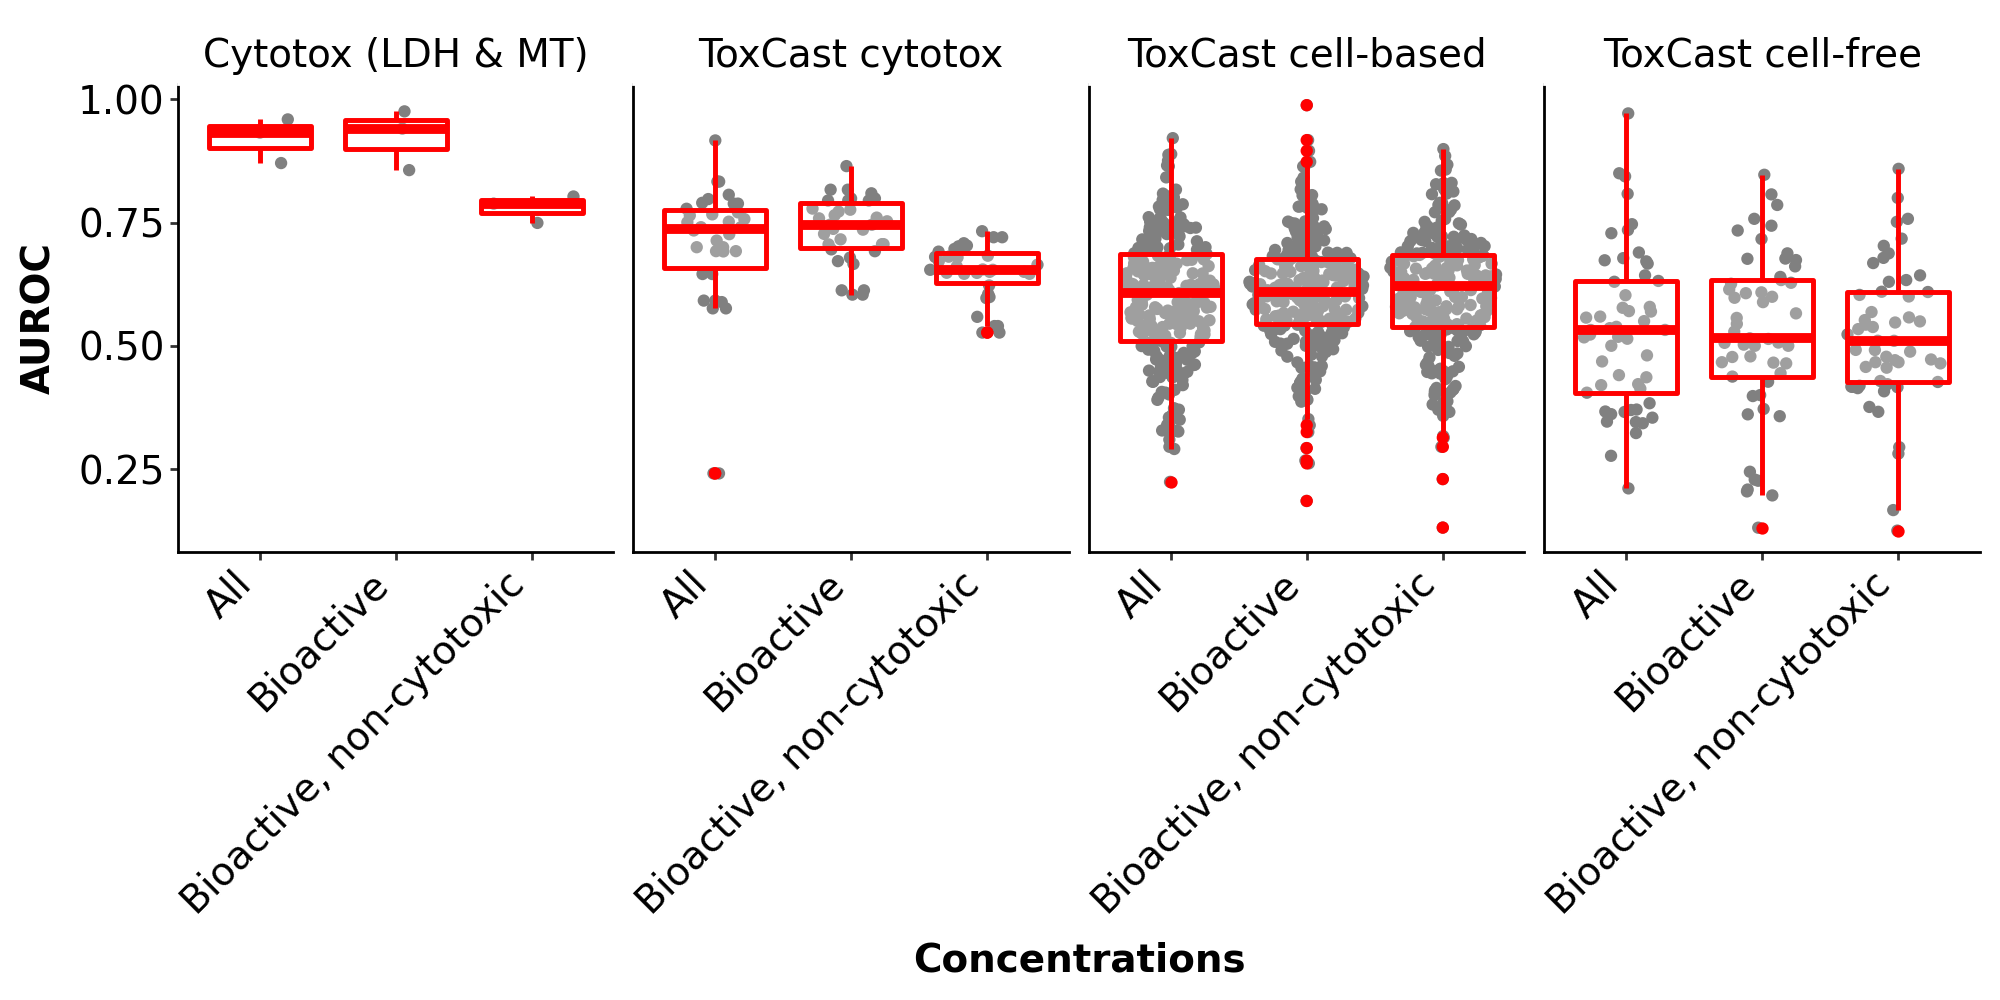

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


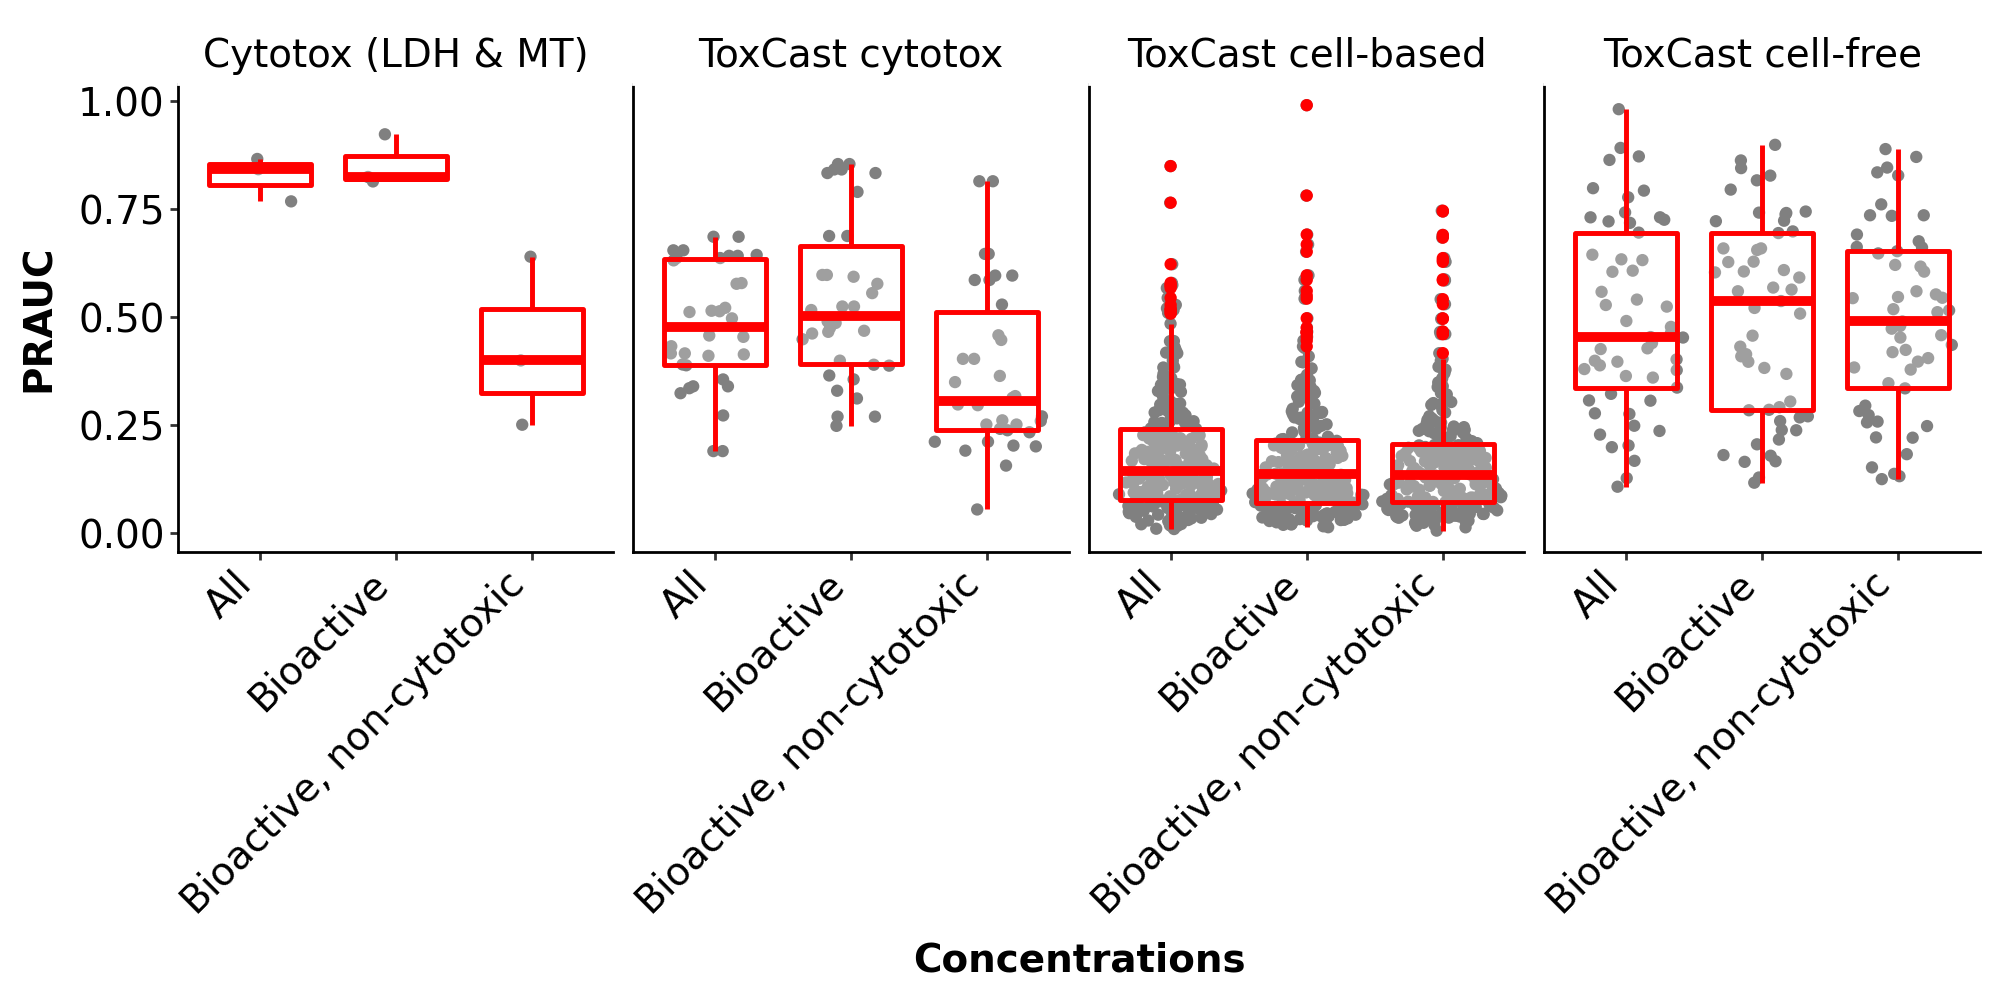

In [4]:
from plotnine import ggplot, aes, geom_sina, geom_boxplot, labs, theme_classic, position_dodge, facet_wrap, theme, element_text, scale_x_discrete, element_rect
import plotnine as pn

pn.options.figure_size = (10, 5)

custom_labels = {
    "axiom_cytotox": "Cytotox (LDH & MT)",
    "toxcast_cytotox": "ToxCast cytotox",
    "toxcast_cellbased": "ToxCast cell-based",
    "toxcast_cellfree": "ToxCast cell-free",
}
def label_func(label_dict):
    return lambda x: label_dict.get(x, x)

plot = (
    ggplot(pred_pandas, aes(x='Metadata_AggType', y='AUROC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Concentrations', y='AUROC') 
    + theme_classic()
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, color='black', size=14, family='Arial'),
        axis_text_y=element_text(color='black', size=14, family='Arial'),
        axis_title_x=element_text(size=14, color='black', weight='bold', family='Arial'),
        axis_title_y=element_text(size=14, color='black', weight='bold', family='Arial'),
        strip_text_x=element_text(size=14, color='black', family='Arial'),
        strip_background=element_rect(fill=None, color='white', size=None, linetype=None),
        )
    + scale_x_discrete(labels={
        "all": "All", 
        "allpod": "Bioactive", 
        "allpodcc": "Bioactive, non-cytotoxic"
    })
)
plot.show()

plot = (
    ggplot(pred_pandas, aes(x='Metadata_AggType', y='PRAUC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Concentrations', y='PRAUC') 
    + theme_classic()
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, color='black', size=14, family='Arial'),
        axis_text_y=element_text(color='black', size=14, family='Arial'),
        axis_title_x=element_text(size=14, color='black', weight='bold', family='Arial'),
        axis_title_y=element_text(size=14, color='black', weight='bold', family='Arial'),
        strip_text_x=element_text(size=14, color='black', family='Arial'),
        strip_background=element_rect(fill=None, color='white', size=None, linetype=None),
        )
    + scale_x_discrete(labels={
        "all": "All", 
        "allpod": "Bioactive", 
        "allpodcc": "Bioactive, non-cytotoxic"
    })
)
plot.show()

In [5]:
warnings.filterwarnings("ignore")

auroc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type"):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "AUROC ~ Metadata_AggType", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Metadata_AggType"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    auroc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
   all   allpod   0.0034 0.9547 -0.0323  0.0391  False
   all allpodcc  -0.1406    0.0 -0.1763 -0.1049   True
allpod allpodcc   -0.144    0.0 -0.1797 -0.1083   True
------------------------------------------------------
P-values: [9.54692075e-01 4.81560950e-05 4.19617521e-05]
Processing Endpoint_type: toxcast_cytotox
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj  lower   upper  reject
-----------------------------------------------------
   all   allpod    0.038   0.0  0.0233  0.0528   True
   all allpodcc  -0.0489   0.0 -0.0637 -0.0342   True
allpod allpodcc   -0.087   0.0 -0.1017 -0.0722   True
-----------------------------------------------------
P-values: [5.38834618e-08 1.26414434e-11 2.43138842e-14]
Processing Endpoint_type: toxcast_cellbas

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
   all   allpod   0.0126 0.0685 -0.0007  0.026  False
   all allpodcc    0.011 0.1281 -0.0023 0.0244  False
allpod allpodcc  -0.0016 0.9579  -0.015 0.0118  False
-----------------------------------------------------
P-values: [0.0684724  0.12808563 0.95790264]
Processing Endpoint_type: toxcast_cellfree
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
   all   allpod  -0.0096 0.8723  -0.055 0.0358  False
   all allpodcc  -0.0129 0.7812 -0.0583 0.0325  False
allpod allpodcc  -0.0033 0.9838 -0.0487 0.0421  False
-----------------------------------------------------
P-values: [0.87232155 0.78117155 0.98381967]


In [6]:
warnings.filterwarnings("ignore")

auroc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type"):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "PRAUC ~ Metadata_AggType", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Metadata_AggType"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    auroc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
   all   allpod   0.0284 0.5658 -0.0532  0.1101  False
   all allpodcc  -0.3956    0.0 -0.4772 -0.3139   True
allpod allpodcc   -0.424    0.0 -0.5057 -0.3423   True
------------------------------------------------------
P-values: [5.65785886e-01 1.44563745e-05 9.62530525e-06]
Processing Endpoint_type: toxcast_cytotox


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
   all   allpod   0.0583 0.1128 -0.0104  0.1269  False
   all allpodcc  -0.1076 0.0009 -0.1762 -0.0389   True
allpod allpodcc  -0.1659    0.0 -0.2345 -0.0972   True
------------------------------------------------------
P-values: [1.12829511e-01 9.32552584e-04 3.00643497e-07]
Processing Endpoint_type: toxcast_cellbased


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
   all   allpod  -0.0091 0.6735 -0.0342 0.0161  False
   all allpodcc   -0.012 0.5048 -0.0371 0.0132  False
allpod allpodcc  -0.0029 0.9612  -0.028 0.0223  False
-----------------------------------------------------
P-values: [0.6734653  0.50479588 0.96123581]
Processing Endpoint_type: toxcast_cellfree
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
   all   allpod   0.0009 0.9997 -0.0865 0.0883  False
   all allpodcc  -0.0063 0.9841 -0.0937 0.0811  False
allpod allpodcc  -0.0072 0.9794 -0.0946 0.0802  False
-----------------------------------------------------
P-values: [0.99967932 0.98414044 0.97938085]


### Compare representations

In [7]:
rep_df = pred_df.filter(pl.col("Metadata_AggType") == "all")

pred_pandas = rep_df.to_pandas()
pred_pandas['Endpoint_type'] = pd.Categorical(
    pred_pandas['Endpoint_type'], 
    categories=["axiom_cytotox", "toxcast_cytotox", "toxcast_cellbased", "toxcast_cellfree"],
    ordered=True
)

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


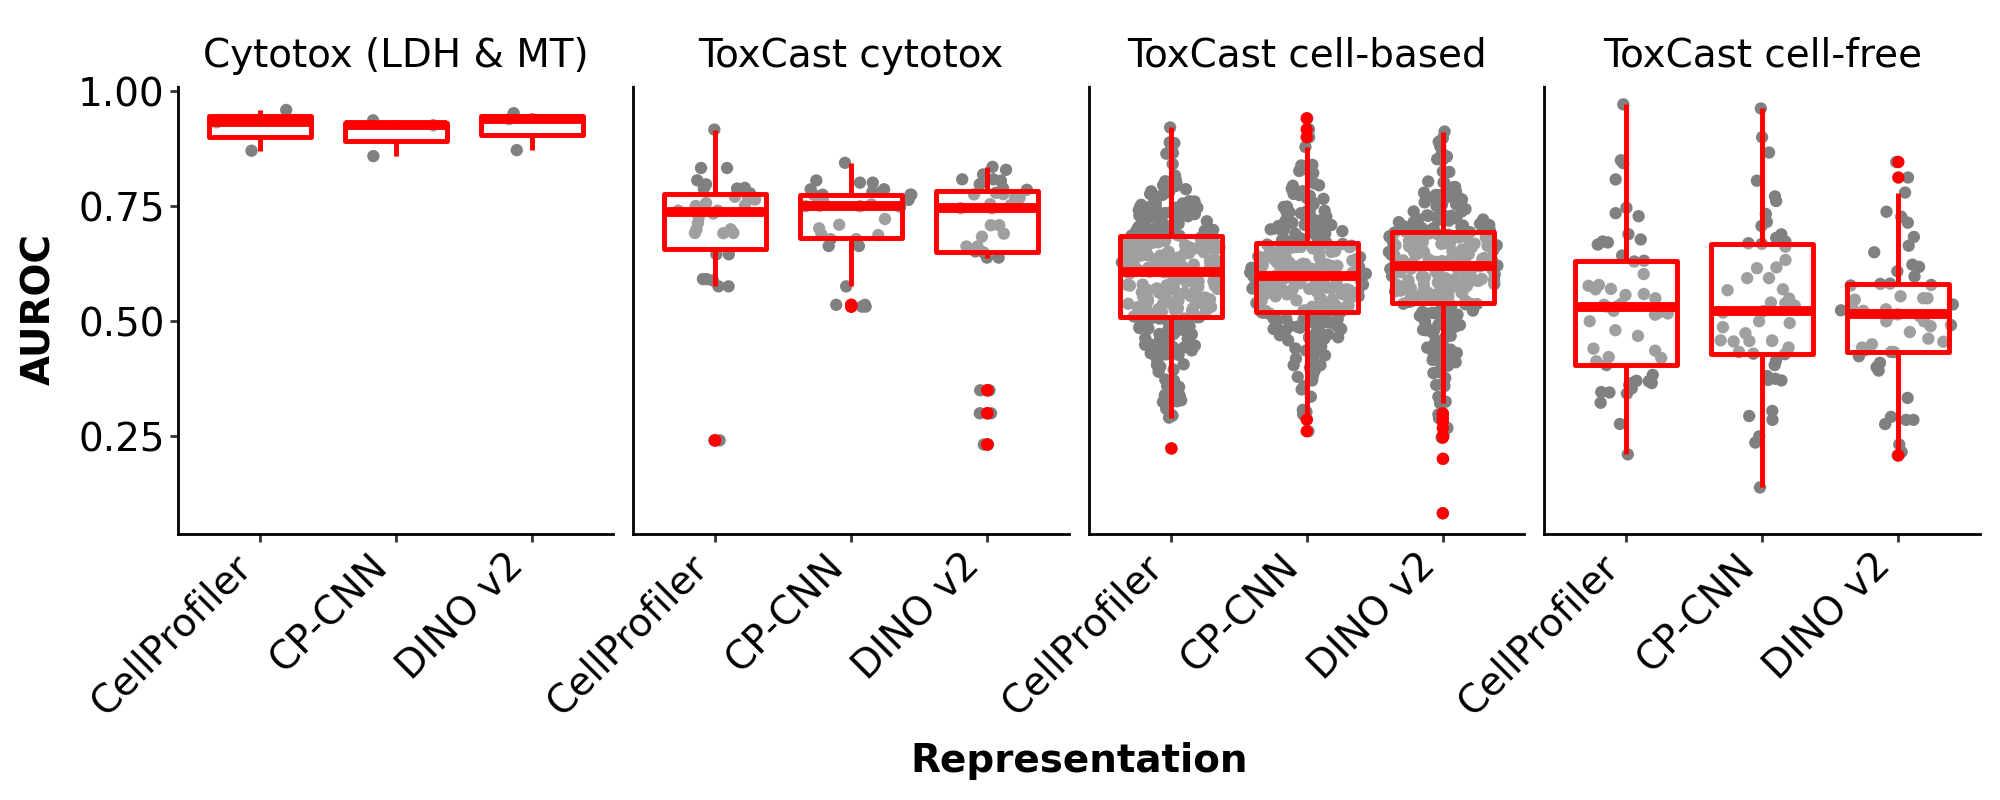

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


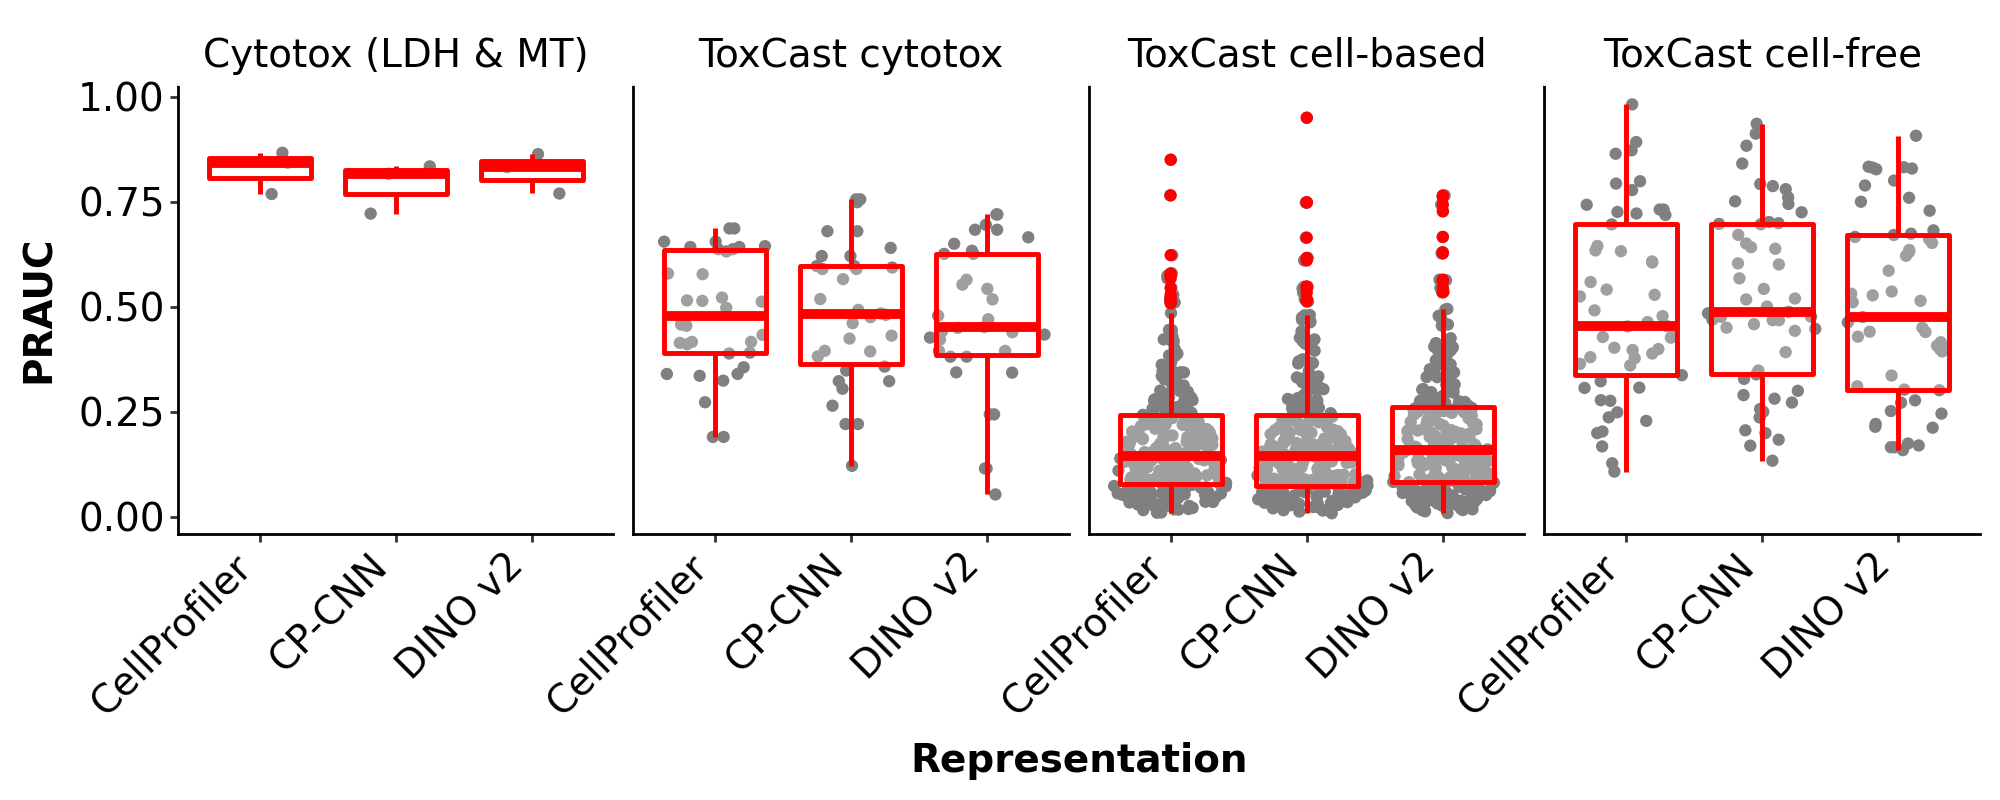

In [8]:
from plotnine import ggplot, aes, geom_sina, geom_boxplot, labs, theme_classic, position_dodge, facet_wrap, theme, element_text, scale_x_discrete, element_rect
import plotnine as pn

pn.options.figure_size = (10, 4)

custom_labels = {
    "axiom_cytotox": "Cytotox (LDH & MT)",
    "toxcast_cytotox": "ToxCast cytotox",
    "toxcast_cellbased": "ToxCast cell-based",
    "toxcast_cellfree": "ToxCast cell-free",
}
def label_func(label_dict):
    return lambda x: label_dict.get(x, x)

plot = (
    ggplot(pred_pandas, aes(x='Feat_type', y='AUROC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Representation', y='AUROC') 
    + theme_classic()
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, color='black', size=14, family='Arial'),
        axis_text_y=element_text(color='black', size=14, family='Arial'),
        axis_title_x=element_text(size=14, color='black', weight='bold', family='Arial'),
        axis_title_y=element_text(size=14, color='black', weight='bold', family='Arial'),
        strip_text_x=element_text(size=14, color='black', family='Arial'),
        strip_background=element_rect(fill=None, color='white', size=None, linetype=None),
        )
    + scale_x_discrete(labels={
        "cellprofiler": "CellProfiler", 
        "dino": "DINO v2", 
        "cpcnn": "CP-CNN"
    })
)
plot.show()

plot = (
    ggplot(pred_pandas, aes(x='Feat_type', y='PRAUC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Representation', y='PRAUC') 
    + theme_classic()
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, color='black', size=14, family='Arial'),
        axis_text_y=element_text(color='black', size=14, family='Arial'),
        axis_title_x=element_text(size=14, color='black', weight='bold', family='Arial'),
        axis_title_y=element_text(size=14, color='black', weight='bold', family='Arial'),
        strip_text_x=element_text(size=14, color='black', family='Arial'),
        strip_background=element_rect(fill=None, color='white', size=None, linetype=None),
        )
    + scale_x_discrete(labels={
        "cellprofiler": "CellProfiler", 
        "dino": "DINO v2", 
        "cpcnn": "CP-CNN"
    })
)
plot.show()

In [9]:
warnings.filterwarnings("ignore")

auroc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type"):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "AUROC ~ Feat_type", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Feat_type"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    auroc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1    group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------------
cellprofiler  cpcnn  -0.0136 0.9224 -0.1221 0.0948  False
cellprofiler   dino   0.0005 0.9999  -0.108 0.1089  False
       cpcnn   dino   0.0141 0.9172 -0.0944 0.1226  False
---------------------------------------------------------
P-values: [0.92238137 0.99990125 0.91720865]
Processing Endpoint_type: toxcast_cytotox
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1    group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------------
cellprofiler  cpcnn   0.0211 0.6203 -0.0327  0.0749  False
cellprofiler   dino  -0.0328 0.3189 -0.0866   0.021  False
       cpcnn   dino  -0.0539 0.0493 -0.1078 -0.0001   True
----------------------------------------------------------
P-values: [0.62026565 0.31893152 0.04932887]
Processin

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1    group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------------
cellprofiler  cpcnn   0.0011 0.9779 -0.0116 0.0138  False
cellprofiler   dino   0.0119 0.0733 -0.0009 0.0246  False
       cpcnn   dino   0.0108 0.1154 -0.0019 0.0235  False
---------------------------------------------------------
P-values: [0.9779064  0.07332357 0.11539434]
Processing Endpoint_type: toxcast_cellfree
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1    group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------------
cellprofiler  cpcnn   0.0062 0.8503 -0.0207 0.0331  False
cellprofiler   dino  -0.0199 0.1918 -0.0468 0.0071  False
       cpcnn   dino   -0.026 0.0605 -0.0529 0.0009  False
---------------------------------------------------------
P-values: [0.85029159 0.19184232 0.06046289]


In [10]:
warnings.filterwarnings("ignore")

auroc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type"):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "PRAUC ~ Feat_type", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Feat_type"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    auroc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1    group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------------
cellprofiler  cpcnn  -0.0351 0.6885 -0.1617 0.0916  False
cellprofiler   dino  -0.0041 0.9947 -0.1307 0.1226  False
       cpcnn   dino    0.031  0.744 -0.0956 0.1576  False
---------------------------------------------------------
P-values: [0.68847352 0.99467211 0.74397419]
Processing Endpoint_type: toxcast_cytotox


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1    group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------------
cellprofiler  cpcnn   0.0026  0.996 -0.0715 0.0768  False
cellprofiler   dino  -0.0136    0.9 -0.0878 0.0605  False
       cpcnn   dino  -0.0163 0.8606 -0.0904 0.0579  False
---------------------------------------------------------
P-values: [0.99602645 0.90001781 0.86057683]
Processing Endpoint_type: toxcast_cellbased


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1    group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------------
cellprofiler  cpcnn   0.0012 0.9937 -0.0245 0.0268  False
cellprofiler   dino   0.0128 0.4726 -0.0129 0.0385  False
       cpcnn   dino   0.0116 0.5384 -0.0141 0.0373  False
---------------------------------------------------------
P-values: [0.99371915 0.47256777 0.53844669]
Processing Endpoint_type: toxcast_cellfree
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
   group1    group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------------
cellprofiler  cpcnn   0.0207 0.8093 -0.0583 0.0998  False
cellprofiler   dino   0.0019 0.9981 -0.0771  0.081  False
       cpcnn   dino  -0.0188 0.8405 -0.0978 0.0603  False
---------------------------------------------------------
P-values: [0.80932011 0.99812733 0.8405372 ]


### Concentrations (cell count baseline)

In [11]:
endpoint_types = ["toxcast_cellbased", "toxcast_cellfree", "toxcast_cytotox", "axiom"]

pred_df = []
for et in endpoint_types:
    preds = pl.read_parquet(f"../compiled_results/compiled_{et}_metrics.parquet")
    preds = preds.with_columns(
        (pl.col("Metadata_Count_0") + pl.col("Metadata_Count_1")).alias("Total_Compounds"),
        pl.lit(et).alias("Endpoint_type")
    )
    pred_df.append(preds)

pred_df = pl.concat(pred_df, how="vertical")
pred_df = pred_df.with_columns(
    pl.when(pl.col("Endpoint_type") == "axiom").then(pl.lit("axiom_cytotox")).otherwise(pl.col("Endpoint_type")).alias("Endpoint_type")
)

pred_df = pred_df.filter(pl.col("Model_type") == "Cellcount_baseline")

In [12]:
conc_df = pred_df.filter(pl.col("Feat_type") == "cellprofiler")

pred_pandas = conc_df.to_pandas()
pred_pandas['Endpoint_type'] = pd.Categorical(
    pred_pandas['Endpoint_type'], 
    categories=["axiom_cytotox", "toxcast_cytotox", "toxcast_cellbased", "toxcast_cellfree"],
    ordered=True
)

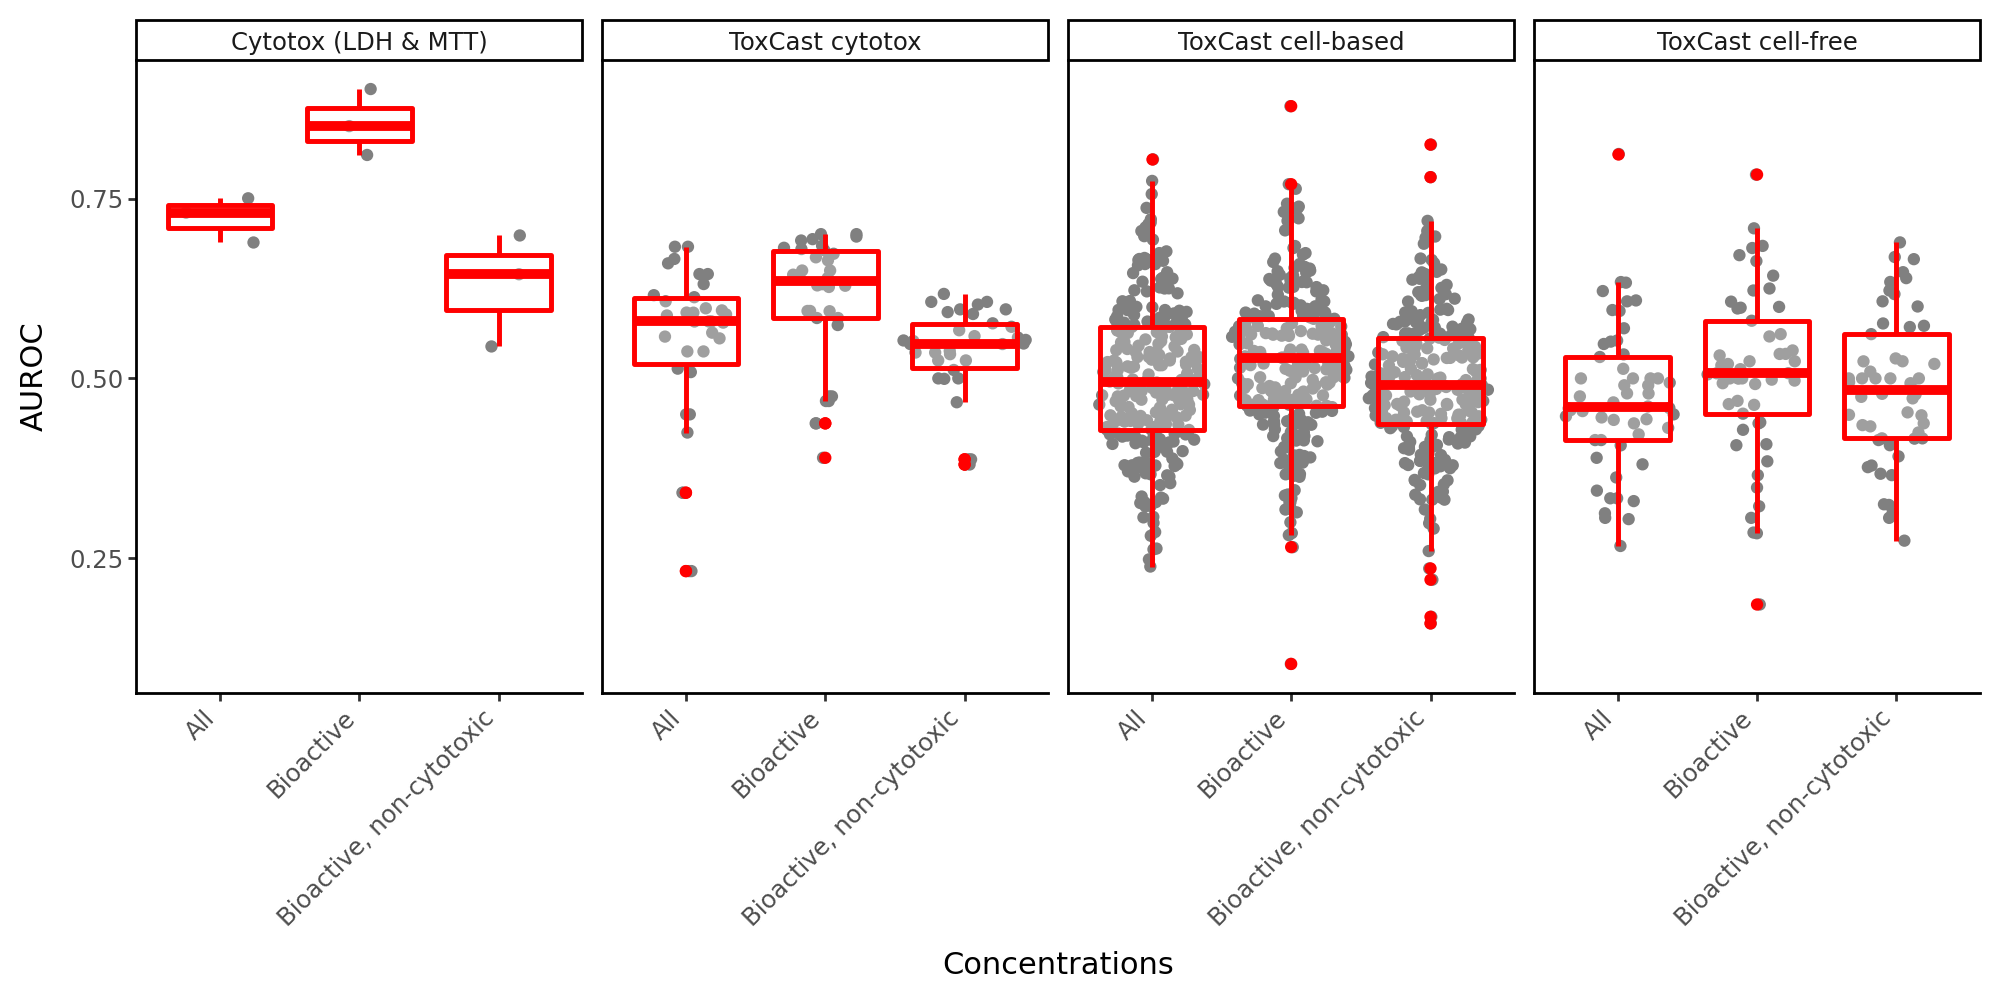

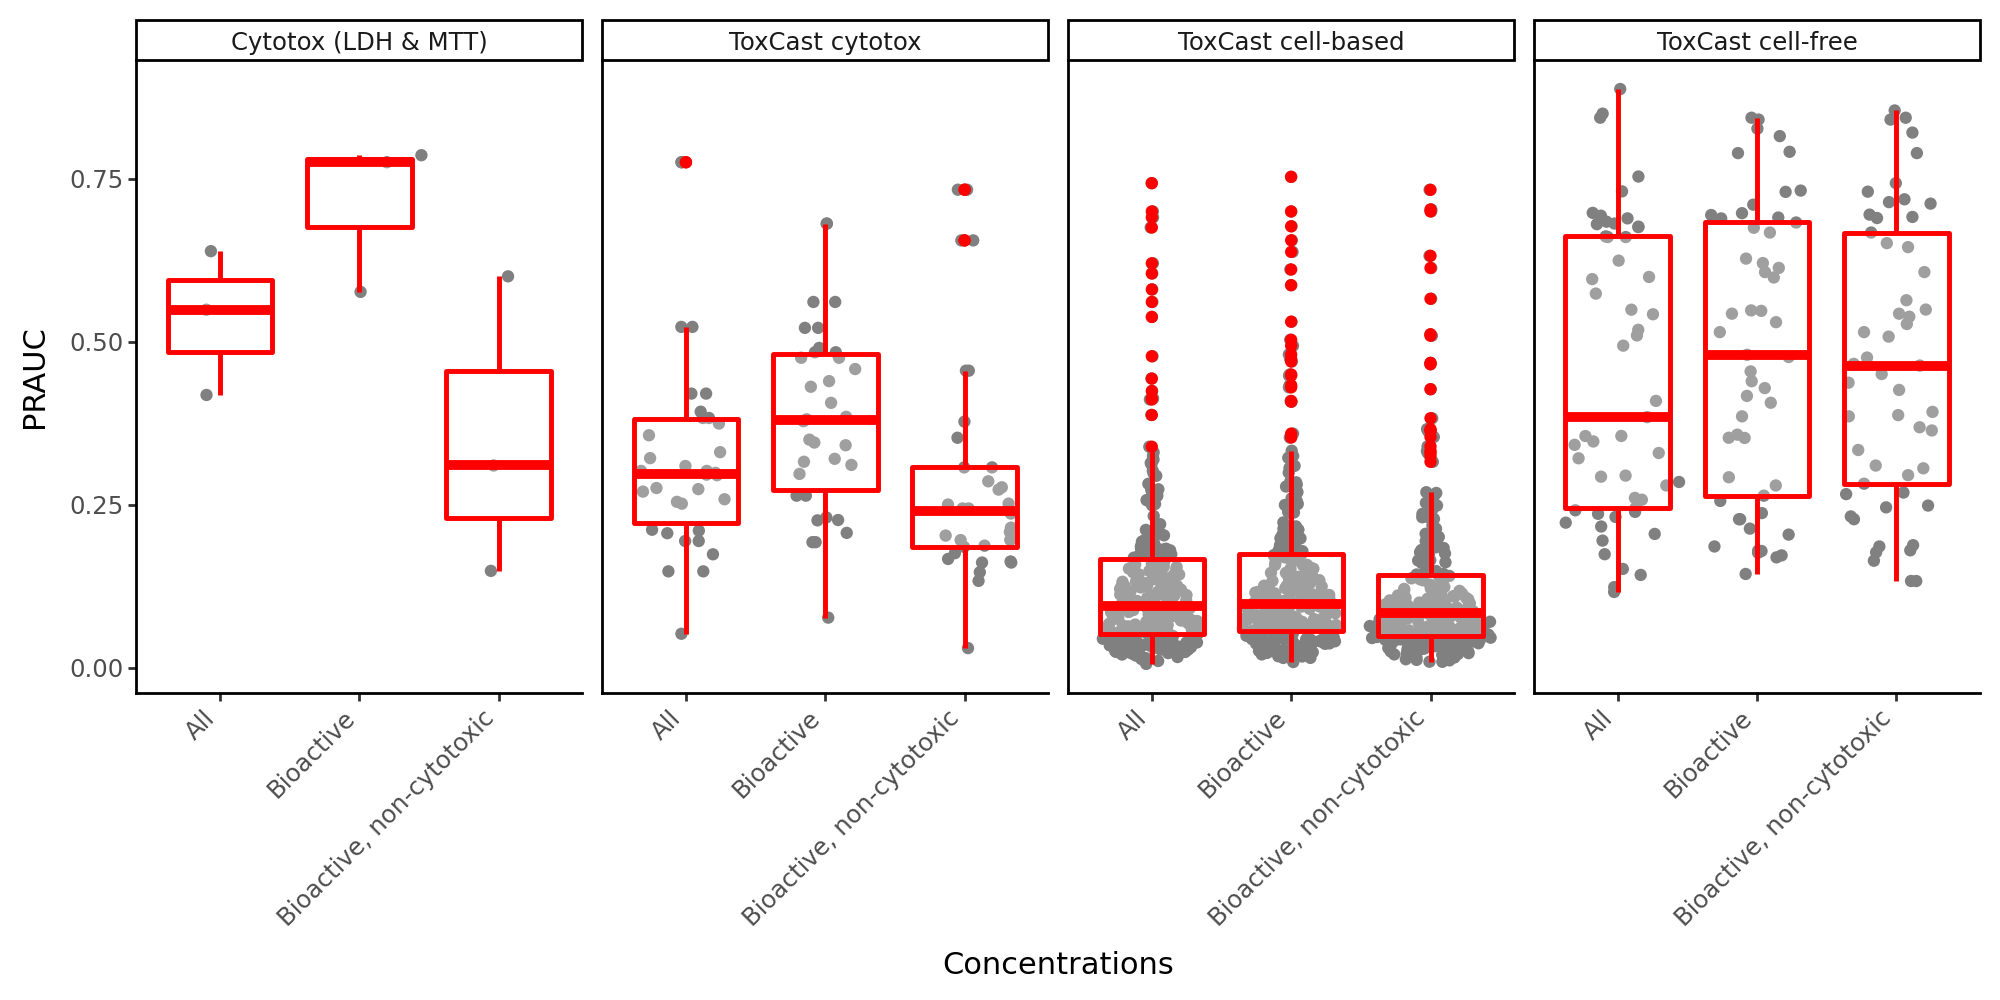

In [13]:
from plotnine import ggplot, aes, geom_sina, geom_boxplot, labs, theme_classic, position_dodge, facet_wrap, theme, element_text, scale_x_discrete
import plotnine as pn

pn.options.figure_size = (10, 5)

custom_labels = {
    "axiom_cytotox": "Cytotox (LDH & MTT)",
    "toxcast_cytotox": "ToxCast cytotox",
    "toxcast_cellbased": "ToxCast cell-based",
    "toxcast_cellfree": "ToxCast cell-free",
}
def label_func(label_dict):
    return lambda x: label_dict.get(x, x)

plot = (
    ggplot(pred_pandas, aes(x='Metadata_AggType', y='AUROC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Concentrations', y='AUROC') 
    + theme_classic()
    + theme(axis_text_x=element_text(angle=45, hjust=1))
    + scale_x_discrete(labels={
        "all": "All", 
        "allpod": "Bioactive", 
        "allpodcc": "Bioactive, non-cytotoxic"
    })
)
plot.show()

plot = (
    ggplot(pred_pandas, aes(x='Metadata_AggType', y='PRAUC')) 
    + geom_sina(color="grey") 
    + geom_boxplot(color="red", alpha=0.25, size=1)
    + facet_wrap("Endpoint_type", ncol=4, labeller=label_func(custom_labels))
    + labs(x='Concentrations', y='PRAUC') 
    + theme_classic()
    + theme(axis_text_x=element_text(angle=45, hjust=1))
    + scale_x_discrete(labels={
        "all": "All", 
        "allpod": "Bioactive", 
        "allpodcc": "Bioactive, non-cytotoxic"
    })
)
plot.show()

In [14]:
warnings.filterwarnings("ignore")

auroc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type"):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "AUROC ~ Metadata_AggType", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Metadata_AggType"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    auroc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj  lower   upper  reject
-----------------------------------------------------
   all   allpod   0.1313   0.0  0.1313  0.1313   True
   all allpodcc  -0.0939   0.0 -0.0939 -0.0939   True
allpod allpodcc  -0.2252   0.0 -0.2252 -0.2252   True
-----------------------------------------------------
P-values: [0. 0. 0.]
Processing Endpoint_type: toxcast_cytotox
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
   all   allpod   0.0608  0.002  0.0194  0.1022   True
   all allpodcc  -0.0122 0.7632 -0.0536  0.0292  False
allpod allpodcc   -0.073 0.0002 -0.1144 -0.0316   True
------------------------------------------------------
P-values: [2.04520815e-03 7.63207284e-01 1.74701439e-04]
Processing Endpoint_type: toxcast_cellbased


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj  lower   upper  reject
-----------------------------------------------------
   all   allpod   0.0208   0.0  0.0096  0.0319   True
   all allpodcc  -0.0085 0.177 -0.0196  0.0027  False
allpod allpodcc  -0.0292   0.0 -0.0404 -0.0181   True
-----------------------------------------------------
P-values: [4.24833965e-05 1.76968533e-01 3.75387121e-09]
Processing Endpoint_type: toxcast_cellfree
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
   all   allpod   0.0356 0.0001  0.0158  0.0555   True
   all allpodcc    0.014 0.2194 -0.0058  0.0339  False
allpod allpodcc  -0.0216 0.0297 -0.0415 -0.0017   True
------------------------------------------------------
P-values: [1.11927348e-04 2.19382981e-01 2.97255360e-02]


In [15]:
warnings.filterwarnings("ignore")

auroc_results = {}

for endpoint_type, group_data in pred_pandas.groupby("Endpoint_type"):
    print(f"Processing Endpoint_type: {endpoint_type}")
    
    # Fit the mixed-effects model
    model = smf.mixedlm(
        "PRAUC ~ Metadata_AggType", 
        group_data, 
        groups=group_data["Metadata_Label"]
    )
    result = model.fit()
    
    # Add fitted values to the subset DataFrame
    group_data["fitted_values"] = result.fittedvalues

    # Perform Tukey's HSD
    mc = MultiComparison(group_data["fitted_values"], group_data["Metadata_AggType"])
    tukey_result = mc.tukeyhsd()
    tukey_pvals = tukey_result.pvalues
    
    # Print results for the current Endpoint_type
    print(tukey_result.summary())
    print("P-values:", tukey_pvals)
    
    # Save results for each Endpoint_type in a dictionary for later reference
    auroc_results[endpoint_type] = {
        "tukey_summary": tukey_result.summary(),
        "tukey_pvalues": tukey_pvals,
        "fitted_model": result
    }

Processing Endpoint_type: axiom_cytotox
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
   all   allpod   0.1771 0.2851 -0.1453  0.4996  False
   all allpodcc  -0.1824 0.2681 -0.5049    0.14  False
allpod allpodcc  -0.3596 0.0326 -0.6821 -0.0371   True
------------------------------------------------------
P-values: [0.28506702 0.26807623 0.0325997 ]
Processing Endpoint_type: toxcast_cytotox


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
   all   allpod   0.0609 0.0879  -0.007  0.1287  False
   all allpodcc  -0.0314  0.516 -0.0992  0.0365  False
allpod allpodcc  -0.0923 0.0047 -0.1601 -0.0244   True
------------------------------------------------------
P-values: [0.08790128 0.51599937 0.00465648]
Processing Endpoint_type: toxcast_cellbased


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
   all   allpod   0.0082 0.6999 -0.0157 0.0321  False
   all allpodcc  -0.0099 0.5935 -0.0339  0.014  False
allpod allpodcc  -0.0181 0.1772 -0.0421 0.0058  False
-----------------------------------------------------
P-values: [0.69990114 0.59350546 0.17720684]
Processing Endpoint_type: toxcast_cellfree
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------
   all   allpod   0.0339 0.6223 -0.0524 0.1202  False
   all allpodcc    0.022 0.8186 -0.0643 0.1083  False
allpod allpodcc  -0.0119 0.9429 -0.0982 0.0744  False
-----------------------------------------------------
P-values: [0.62228562 0.8185694  0.94291495]
